# Rules of ML in Production: Churn Demo

## Contexto

Este paper de Google plantea que los problemas reales de Machine Learning no suelen ser solo de modelo, sino de ingeniería y producción.

En esta demo vamos a mostrar dos cosas:

1. Un modelo simple puede ser suficiente como punto de partida.
2. Un modelo que funciona bien offline puede degradarse en producción.

Vamos a usar un ejemplo sintético de churn para ilustrarlo.

## Setup

Fijamos una semilla para que la demo sea reproducible y definimos funciones reutilizables.

Esto es importante porque en Machine Learning en producción no alcanza con entrenar un modelo una vez: también necesitamos código claro, repetible y fácil de mantener.

En esta primera celda preparamos:

- generación de datos sintéticos de churn
- simulación de drift en producción
- evaluación por accuracy
- gráficos simples para comparar resultados
- una función básica para detectar train-serving skew

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
FEATURE_NAMES = [f"feature_{i}" for i in range(8)]


def create_training_data(seed=RANDOM_SEED):
    # Synthetic data shaped like a production churn problem.
    X, y = make_classification(
        n_samples=2200,
        n_features=8,
        n_informative=6,
        n_redundant=2,
        n_clusters_per_class=1,
        class_sep=1.9,
        flip_y=0.02,
        random_state=seed,
    )
    return X, y


def simulate_serving_drift(X, y, seed=RANDOM_SEED, label_flip_rate=0.07):
    rng = np.random.default_rng(seed)
    X_serving = X.copy()

    # Demand and behavior changes after deployment.
    X_serving[:, 1] += 1.0
    X_serving[:, 2] *= 0.7
    X_serving[:, 4] += 0.8
    X_serving[:, 7] *= 0.75

    # Train-serving skew from an upstream scaling mismatch.
    X_serving[:, 3] *= 1.25
    X_serving += rng.normal(0.0, 0.35, size=X_serving.shape)

    y_serving = y.copy()
    flip_mask = rng.random(y_serving.shape[0]) < label_flip_rate
    y_serving[flip_mask] = 1 - y_serving[flip_mask]

    return X_serving, y_serving


def evaluate_accuracy(model, X_eval, y_eval):
    return accuracy_score(y_eval, model.predict(X_eval))


def plot_accuracy_bars(title, labels, values, colors):
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    bars = ax.bar(labels, values, color=colors, width=0.6)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )
    fig.tight_layout()
    plt.show()


def report_feature_shift(X_reference, X_serving, feature_indices, threshold=0.35):
    print("Skew check (mean shift):")
    print("feature       reference_mean   serving_mean   abs_shift")

    max_shift = 0.0
    for idx in feature_indices:
        ref_mean = float(np.mean(X_reference[:, idx]))
        srv_mean = float(np.mean(X_serving[:, idx]))
        shift = abs(srv_mean - ref_mean)
        max_shift = max(max_shift, shift)
        print(
            f"{FEATURE_NAMES[idx]:<12} {ref_mean:>14.3f} {srv_mean:>14.3f} {shift:>11.3f}"
        )

    if max_shift > threshold:
        print(f"ALERT: train-serving skew detected (max shift={max_shift:.3f} > {threshold:.3f})")
    else:
        print(f"OK: no major skew detected (max shift={max_shift:.3f})")

## Demo 1: Empezar simple

Primero comparamos dos modelos:

- Un baseline simple: Logistic Regression.
- Un modelo más flexible: Random Forest.

La idea no es ver cuál es “mejor” en general, sino mostrar que un modelo simple muchas veces ya es suficiente como punto de partida.

Esto se relaciona con:

- Rule #4: Keep the first model simple.
- Rule #14: Start with an interpretable model.

En producción, empezar simple ayuda porque el modelo es más fácil de debuggear, explicar, mantener e iterar.

DEMO 1 | BASELINE VS FLEXIBLE MODEL
Validation accuracy (offline):
- Logistic Regression (baseline): 0.983
- Random Forest (flexible):       0.979
- Gap (flex - baseline):          -0.005
Takeaway: start simple and interpretable first.
Rule #4 + Rule #14


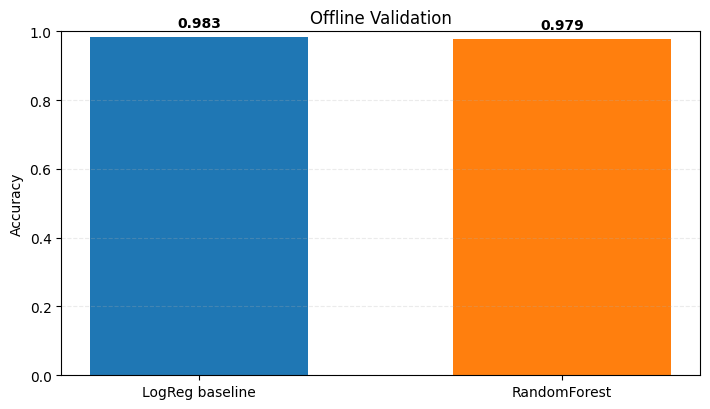

In [10]:
# Demo 1: keep the first production model simple (Rule #4, Rule #14)
X_all, y_all = create_training_data()
X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y_all,
 )

baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
flex_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=4,
    min_samples_leaf=8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
 )

baseline_model.fit(X_train, y_train)
flex_model.fit(X_train, y_train)

baseline_val_acc = evaluate_accuracy(baseline_model, X_val, y_val)
flex_val_acc = evaluate_accuracy(flex_model, X_val, y_val)
accuracy_gap = flex_val_acc - baseline_val_acc

print("=" * 62)
print("DEMO 1 | BASELINE VS FLEXIBLE MODEL")
print("Validation accuracy (offline):")
print(f"- Logistic Regression (baseline): {baseline_val_acc:.3f}")
print(f"- Random Forest (flexible):       {flex_val_acc:.3f}")
print(f"- Gap (flex - baseline):          {accuracy_gap:+.3f}")
print("Takeaway: start simple and interpretable first.")
print("Rule #4 + Rule #14")

plot_accuracy_bars(
    title="Offline Validation",
    labels=["LogReg baseline", "RandomForest"],
    values=[baseline_val_acc, flex_val_acc],
    colors=["#1f77b4", "#ff7f0e"],
)

### Resultado de la Demo 1

En este caso, Logistic Regression obtiene una accuracy cercana a 0.983, mientras que Random Forest obtiene aproximadamente 0.979.

El modelo más flexible no mejora al baseline simple.

La conclusión principal es:

> Empezar simple no solo facilita el debugging y el mantenimiento, sino que muchas veces no implica perder performance.

En un sistema real, esto es importante porque agregar complejidad demasiado temprano puede dificultar la explicación del modelo, la detección de errores y la evolución del sistema.

## Demo 2: Offline vs Producción

Ahora usamos el mismo baseline simple, pero lo evaluamos en dos escenarios:

1. Datos de validación offline.
2. Datos simulando producción con drift y train-serving skew.

La pregunta que queremos responder es:

> ¿Qué pasa cuando los datos cambian después de deployar el modelo?

Esta parte se relaciona con la Rule #37: medir el train-serving skew.

La idea central es que un buen resultado offline no garantiza que el modelo vaya a funcionar igual de bien en producción.

DEMO 2 | OFFLINE VS SERVING
- Offline / validation accuracy: 0.983
- Serving accuracy (with drift): 0.892
- Performance drop:              0.091
Rule #37: always measure train-serving skew.
Skew check (mean shift):
feature       reference_mean   serving_mean   abs_shift
feature_1            -0.051          0.947       0.999
feature_3             1.937          2.414       0.477
feature_4            -1.906         -1.105       0.802
feature_7             0.913          0.670       0.243
ALERT: train-serving skew detected (max shift=0.999 > 0.350)


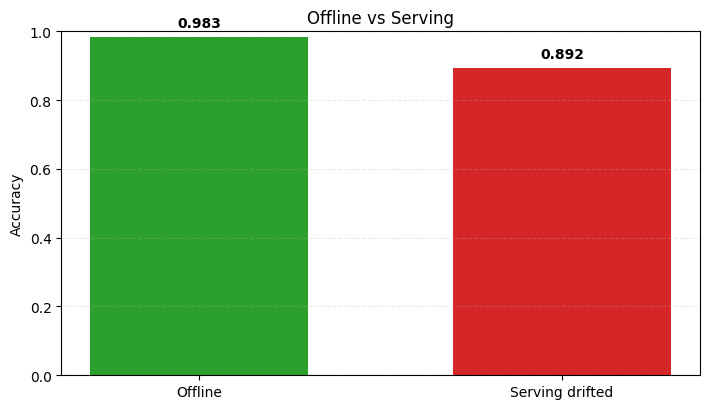

In [11]:
# Demo 2: good offline metrics can degrade in production
offline_accuracy = evaluate_accuracy(baseline_model, X_val, y_val)
X_serving, y_serving = simulate_serving_drift(X_val, y_val)
serving_accuracy = evaluate_accuracy(baseline_model, X_serving, y_serving)
performance_drop = offline_accuracy - serving_accuracy

print("=" * 62)
print("DEMO 2 | OFFLINE VS SERVING")
print(f"- Offline / validation accuracy: {offline_accuracy:.3f}")
print(f"- Serving accuracy (with drift): {serving_accuracy:.3f}")
print(f"- Performance drop:              {performance_drop:.3f}")
print("Rule #37: always measure train-serving skew.")

report_feature_shift(
    X_reference=X_val,
    X_serving=X_serving,
    feature_indices=[1, 3, 4, 7],
    threshold=0.35,
)

plot_accuracy_bars(
    title="Offline vs Serving",
    labels=["Offline", "Serving drifted"],
    values=[offline_accuracy, serving_accuracy],
    colors=["#2ca02c", "#d62728"],
)

### Resultado de la Demo 2

El modelo obtiene una accuracy offline cercana a 0.983, pero cuando lo evaluamos en datos simulando producción, la accuracy cae aproximadamente a 0.892.

Esto muestra una caída de performance de alrededor de 0.09.

La parte importante no es solo que bajó la accuracy, sino por qué pudo haber pasado.

En la tabla de skew comparamos la media de algunas features entre los datos de referencia y los datos de serving. Vemos que varias features cambiaron significativamente, por eso se dispara una alerta de train-serving skew.

La conclusión es:

> El problema no siempre está en el modelo; muchas veces el problema es que los datos de producción ya no se parecen a los datos con los que evaluamos originalmente.

Esto refuerza la idea de que en producción hay que monitorear tanto las métricas del modelo como la distribución de los datos.

## Conclusiones finales

Como conclusión, llegamos a estas tres ideas principales:

- Start simple  
  Un baseline simple es un excelente punto de partida.

- Good offline metrics are not enough  
  Buen rendimiento offline no garantiza buen rendimiento real.

- Monitor production drift / skew  
  Es necesario monitorear los datos y el comportamiento del modelo en producción.

En resumen:

> Machine Learning en producción no es solo entrenar modelos, es mantenerlos funcionando correctamente en el tiempo.

## Mensaje final

La principal enseñanza del paper es que el desafío real de Machine Learning no es solo elegir el mejor modelo, sino construir sistemas que funcionen bien en producción y se mantengan estables cuando los datos cambian.